In [ ]:
import pandas as pd
import numpy as np

stolen_water = pd.read_csv('./csvs/consum din cauza irigării.csv', sep=';')

stolen_water['x'] = pd.to_datetime(stolen_water['x'], format='%d/%m/%Y %H:%M')

stolen_water['Date'] = pd.to_datetime(stolen_water['x']).dt.date.astype('datetime64[ns]')
stolen_water['Hour'] = pd.to_datetime(stolen_water['x'], format='%d/%m/%Y %H:%M').dt.hour

# stolen_water.info()

# missing_values = stolen_water.isnull().sum()
# print("Valori lipsă:\n", missing_values)

# print(stolen_water.describe())

hourly_stats = stolen_water.groupby("Hour")["y"].agg(["mean", "median", "std"])

threshold_95 = np.percentile(stolen_water["y"], 95)
stolen_water["is_anomalous"] = stolen_water["y"] > threshold_95

hourly_profile = stolen_water.groupby("Hour")["y"].mean()
stolen_water["alert_threshold"] = stolen_water["Hour"].map(lambda x: hourly_stats.loc[x, "mean"] + 2 * hourly_stats.loc[x, "std"])

stolen_water["anomaly_type"] = np.where(
    stolen_water["y"] > threshold_95, "Potential Theft",
    np.where(stolen_water["y"] > stolen_water["alert_threshold"], "Possible Leak", "Normal Usage")
)

# print(f"Prag percentilă 95: {threshold_95}")
# print("Anomalii detectate:\n", stolen_water[stolen_water["is_anomalous"]])
# print("Profil consum normal:\n", hourly_profile)

# stolen_water.to_csv("procesat_consum_irigare.csv", index=False)

            mean  median         std
Hour                                
0      30.375000    29.0    2.753785
1      30.750000    30.0    2.977695
2      32.000000    31.0    3.585686
3      32.187500    31.0    3.350995
4      31.125000    30.0    2.986079
5      31.125000    30.0    3.222318
6      31.625000    31.0    2.362908
7      38.562500    39.0    3.999479
8      48.000000    50.0    7.097535
9      48.352941    50.0    6.363383
10     50.352941    52.0    6.632695
11     51.058824    52.0    6.703270
12     50.764706    52.0    6.280221
13     49.176471    51.0    6.701075
14     49.823529    52.0    7.576570
15    238.941176    53.0  333.559116
16     48.470588    51.0    7.795172
17    293.705882    51.0  576.127239
18    617.705882    52.0  790.629319
19    117.941176    49.0  296.959271
20     42.588235    44.0    4.730999
21     33.294118    33.0    2.616408
22     30.764706    30.0    2.704843
23     31.000000    30.0    2.221111


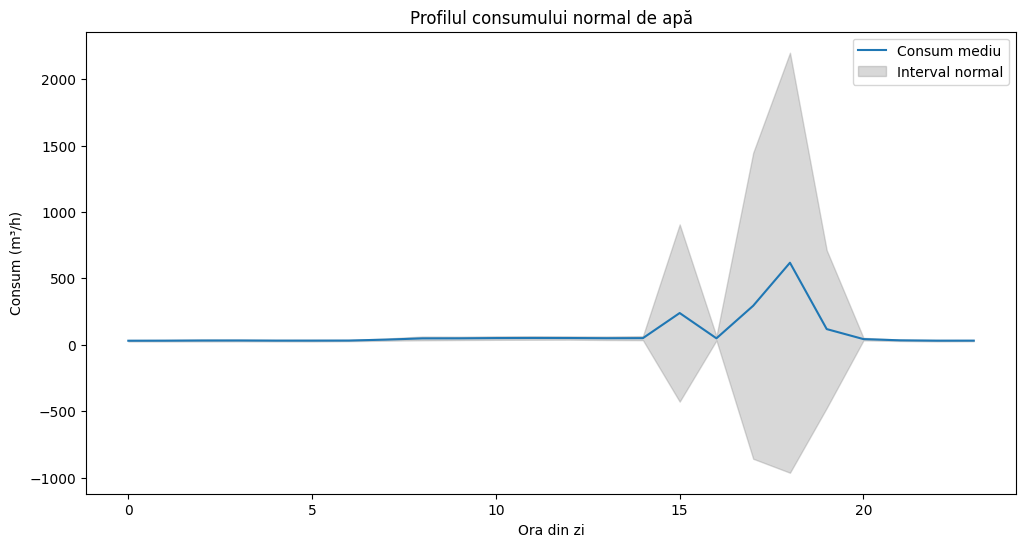

Profil consum normal:
             mean  median         std
Hour                                
0      30.375000    29.0    2.753785
1      30.750000    30.0    2.977695
2      32.000000    31.0    3.585686
3      32.187500    31.0    3.350995
4      31.125000    30.0    2.986079
5      31.125000    30.0    3.222318
6      31.625000    31.0    2.362908
7      38.562500    39.0    3.999479
8      48.000000    50.0    7.097535
9      48.352941    50.0    6.363383
10     50.352941    52.0    6.632695
11     51.058824    52.0    6.703270
12     50.764706    52.0    6.280221
13     49.176471    51.0    6.701075
14     49.823529    52.0    7.576570
15    238.941176    53.0  333.559116
16     48.470588    51.0    7.795172
17    293.705882    51.0  576.127239
18    617.705882    52.0  790.629319
19    117.941176    49.0  296.959271
20     42.588235    44.0    4.730999
21     33.294118    33.0    2.616408
22     30.764706    30.0    2.704843
23     31.000000    30.0    2.221111
Anomalii detect

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Citirea fișierului CSV
stolen_water = pd.read_csv('./csvs/consum din cauza irigării.csv', sep=';')

# Conversia timestamp-ului în format datetime
stolen_water['x'] = pd.to_datetime(stolen_water['x'], format='%d/%m/%Y %H:%M')

# Separarea datei și orei
stolen_water['Date'] = pd.to_datetime(stolen_water['x']).dt.date.astype('datetime64[ns]')
stolen_water['Hour'] = pd.to_datetime(stolen_water['x'], format='%d/%m/%Y %H:%M').dt.hour

# Crearea profilului normal de consum
hourly_profile = stolen_water.groupby("Hour")["y"].agg(["mean", "median", "std"])

# Definirea pragului de alertă: consumul normal ± 2 * deviația standard
stolen_water["alert_threshold"] = stolen_water["Hour"].map(lambda x: hourly_profile.loc[x, "mean"] + 2 * hourly_profile.loc[x, "std"])

# Detectarea anomaliilor față de profilul normal
stolen_water["is_anomalous"] = stolen_water["y"] > stolen_water["alert_threshold"]

# Vizualizarea consumului orar
plt.figure(figsize=(12, 6))
plt.plot(hourly_profile.index, hourly_profile["mean"], label="Consum mediu")
plt.fill_between(hourly_profile.index, hourly_profile["mean"] - 2 * hourly_profile["std"], 
                 hourly_profile["mean"] + 2 * hourly_profile["std"], color='gray', alpha=0.3, label="Interval normal")
plt.xlabel("Ora din zi")
plt.ylabel("Consum (m³/h)")
plt.title("Profilul consumului normal de apă")
plt.legend()
plt.show()

# Afișăm profilul normal al consumului și anomaliile detectate
print("Profil consum normal:\n", hourly_profile)
print("Anomalii detectate:\n", stolen_water[stolen_water["is_anomalous"]])

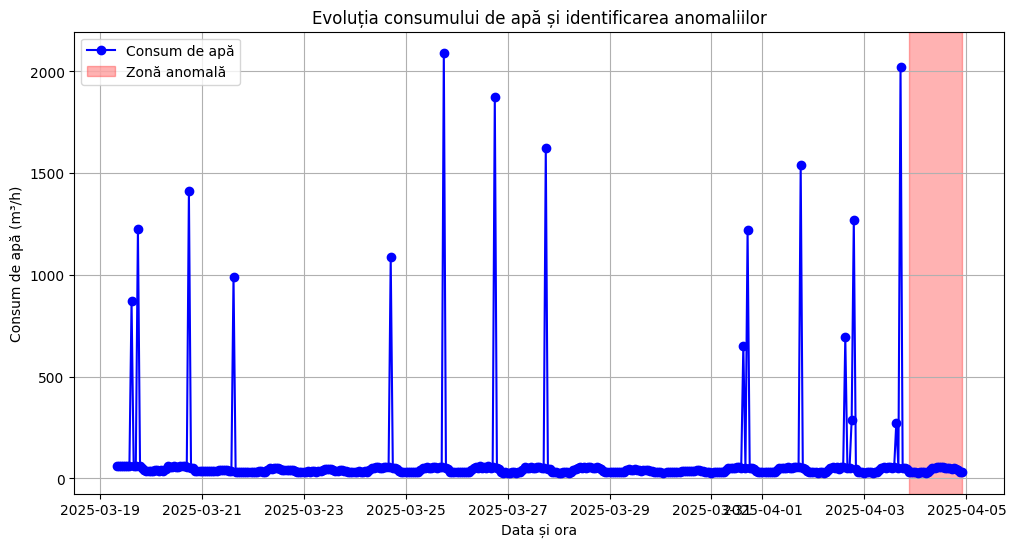

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Citirea datelor din fișier
df = pd.read_csv('./csvs/consum din cauza irigării.csv', sep=';')

# Convertirea timestamp-ului
df["x"] = pd.to_datetime(df["x"], format="%d/%m/%Y %H:%M")

# Crearea graficului de consum
plt.figure(figsize=(12, 6))
plt.plot(df["x"], df["y"], marker='o', linestyle='-', color='blue', label="Consum de apă")

# Evidențierea anomaliilor (după 3 aprilie)
plt.axvspan(pd.to_datetime("3/4/2025 21:00", format="%d/%m/%Y %H:%M"), 
            pd.to_datetime("4/4/2025 22:00", format="%d/%m/%Y %H:%M"), 
            color='red', alpha=0.3, label="Zonă anomală")

plt.xlabel("Data și ora")
plt.ylabel("Consum de apă (m³/h)")
plt.title("Evoluția consumului de apă și identificarea anomaliilor")
plt.legend()
plt.grid()
plt.show()

Distribuția anomaliilor:
 anomaly_type
Normal Usage       384
Possible Leak       13
Potential Theft      1
Name: count, dtype: int64


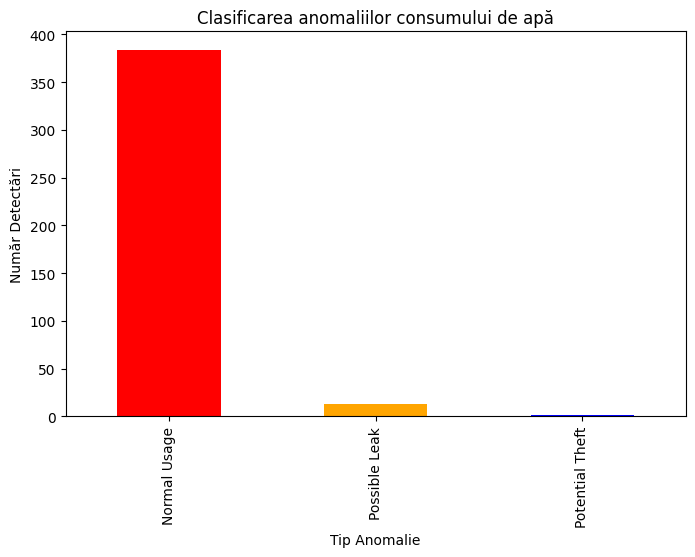

In [12]:
import pandas as pd
import numpy as np

# Citirea fișierului procesat anterior
stolen_water = pd.read_csv("procesat_consum_irigare.csv")

# Definirea pragurilor pentru clasificarea anomaliilor
stolen_water["anomaly_type"] = np.where(
    stolen_water["y"] > stolen_water["alert_threshold"] * 1.5, "Potential Theft",
    np.where(stolen_water["y"] > stolen_water["alert_threshold"], "Possible Leak", "Normal Usage")
)

# Contorizarea fiecărui tip de anomalie
anomaly_counts = stolen_water["anomaly_type"].value_counts()
print("Distribuția anomaliilor:\n", anomaly_counts)

# Vizualizarea distribuției anomaliilor
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
anomaly_counts.plot(kind="bar", color=["red", "orange", "blue"])
plt.xlabel("Tip Anomalie")
plt.ylabel("Număr Detectări")
plt.title("Clasificarea anomaliilor consumului de apă")
plt.show()

# Salvarea datasetului procesat cu anomaliile clasificate
stolen_water.to_csv("procesat_consum_final.csv", index=False)

Mean Absolute Error (MAE): 58.33 m³/h


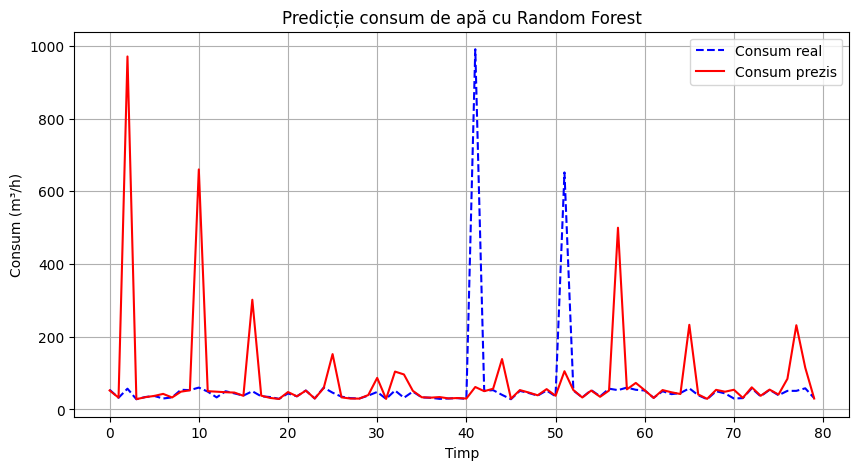

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error

# 1. Citirea fișierului CSV
stolen_water = pd.read_csv('./csvs/consum din cauza irigării.csv', sep=';')

# 2. Conversia timestamp-ului în format datetime
stolen_water['x'] = pd.to_datetime(stolen_water['x'], format='%d/%m/%Y %H:%M')

# 3. Separarea datei și orei pentru caracteristici suplimentare
stolen_water['Date'] = pd.to_datetime(stolen_water['x']).dt.date.astype('datetime64[ns]')
stolen_water['Hour'] = pd.to_datetime(stolen_water['x'], format='%d/%m/%Y %H:%M').dt.hour
stolen_water['Day'] = stolen_water['x'].dt.day
stolen_water['Day_of_Week'] = stolen_water['x'].dt.dayofweek  # 0 = Luni, 6 = Duminică

# 4. Crearea setului de antrenare (X = caracteristici, y = consumul de apă)
X = stolen_water[["Hour", "Day", "Day_of_Week"]]
y = stolen_water["y"]

# 5. Separăm datele în set de antrenare și testare
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 6. Crearea și antrenarea modelului Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 7. Predicția consumului pe setul de testare
y_pred = rf_model.predict(X_test)

# 8. Evaluarea performanței modelului
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error (MAE): {mae:.2f} m³/h")

# 9. Vizualizarea predicțiilor vs. valorile reale
plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label="Consum real", linestyle="dashed", color="blue")
plt.plot(y_pred, label="Consum prezis", linestyle="solid", color="red")
plt.xlabel("Timp")
plt.ylabel("Consum (m³/h)")
plt.title("Predicție consum de apă cu Random Forest")
plt.legend()
plt.grid()
plt.show()

p-value: 0.0
Seria este staționară, utilizăm ARIMA direct.


c:\Users\lungu\pyworkshop\env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\lungu\pyworkshop\env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\lungu\pyworkshop\env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\lungu\pyworkshop\env\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starti

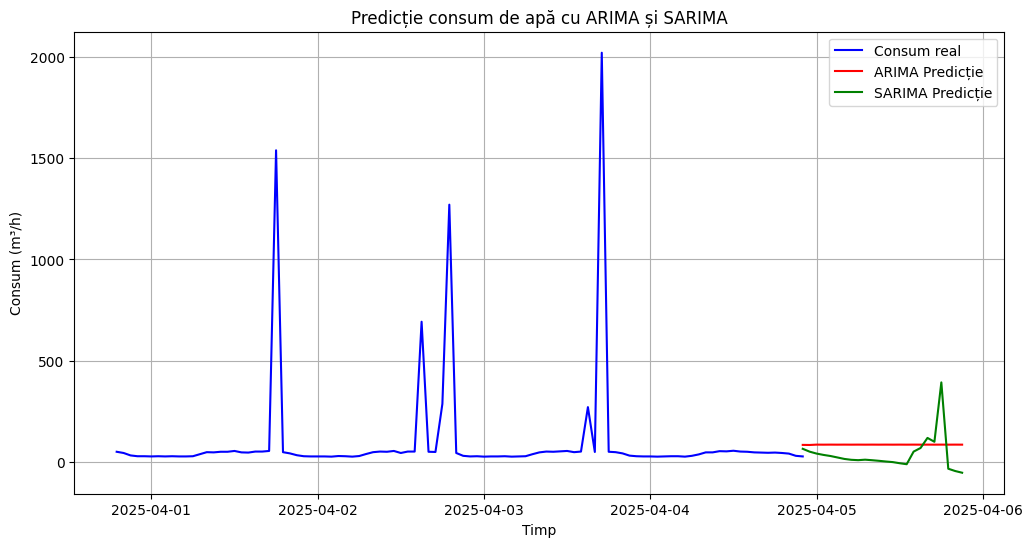

In [ ]:
    import pandas as pd
    import numpy as np
    import matplotlib.pyplot as plt
    from statsmodels.tsa.stattools import adfuller
    from statsmodels.tsa.arima.model import ARIMA
    from statsmodels.tsa.statespace.sarimax import SARIMAX

    # 1. Citirea fișierului procesat
    stolen_water = pd.read_csv("procesat_consum_irigare.csv")

    # 2. Conversia timestamp-ului în format datetime
    stolen_water['x'] = pd.to_datetime(stolen_water['x'], format='%Y-%m-%d %H:%M:%S')

    # 3. Setăm indexul pe timp și sortăm datele
    stolen_water.set_index("x", inplace=True)
    stolen_water = stolen_water.sort_index()

    # 4. Testul de staționaritate (Dickey-Fuller)
    result = adfuller(stolen_water['y'])
    print(f"p-value: {result[1]}")
    if result[1] > 0.05:
        print("Seria nu este staționară, aplicăm diferențierea.")
        stolen_water['y_diff'] = stolen_water['y'].diff().dropna()
        data_used = stolen_water['y_diff']
    else:
        print("Seria este staționară, utilizăm ARIMA direct.")
        data_used = stolen_water['y']

    # 5. Antrenarea modelului ARIMA optimizat
    model_arima = ARIMA(data_used, order=(3,1,2))  # Ajustăm parametrii pentru o predicție mai bună
    model_fit_arima = model_arima.fit()

    # 6. Antrenarea modelului SARIMA pentru sezonalitate zilnică
    model_sarima = SARIMAX(stolen_water['y'], order=(3,1,2), seasonal_order=(1,1,1,24))
    model_fit_sarima = model_sarima.fit()

    # 7. Predicția pentru următoarele 24 de ore
    forecast_arima = model_fit_arima.forecast(steps=24)
    forecast_sarima = model_fit_sarima.forecast(steps=24)

    # 8. Vizualizarea predicțiilor
    plt.figure(figsize=(12, 6))
    plt.plot(stolen_water.index[-100:], stolen_water["y"].iloc[-100:], label="Consum real", color='blue')
    plt.plot(pd.date_range(stolen_water.index[-1], periods=24, freq='H'), forecast_arima, label="ARIMA Predicție", color='red')
    plt.plot(pd.date_range(stolen_water.index[-1], periods=24, freq='H'), forecast_sarima, label="SARIMA Predicție", color='green')
    plt.xlabel("Timp")
    plt.ylabel("Consum (m³/h)")
    plt.title("Predicție consum de apă cu ARIMA și SARIMA")
    plt.legend()
    plt.grid()
    plt.show()

c:\Users\lungu\pyworkshop\env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\lungu\pyworkshop\env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\lungu\pyworkshop\env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\lungu\pyworkshop\env\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_pr

ARIMA RMSE: 313.73
SARIMA RMSE: 325.92


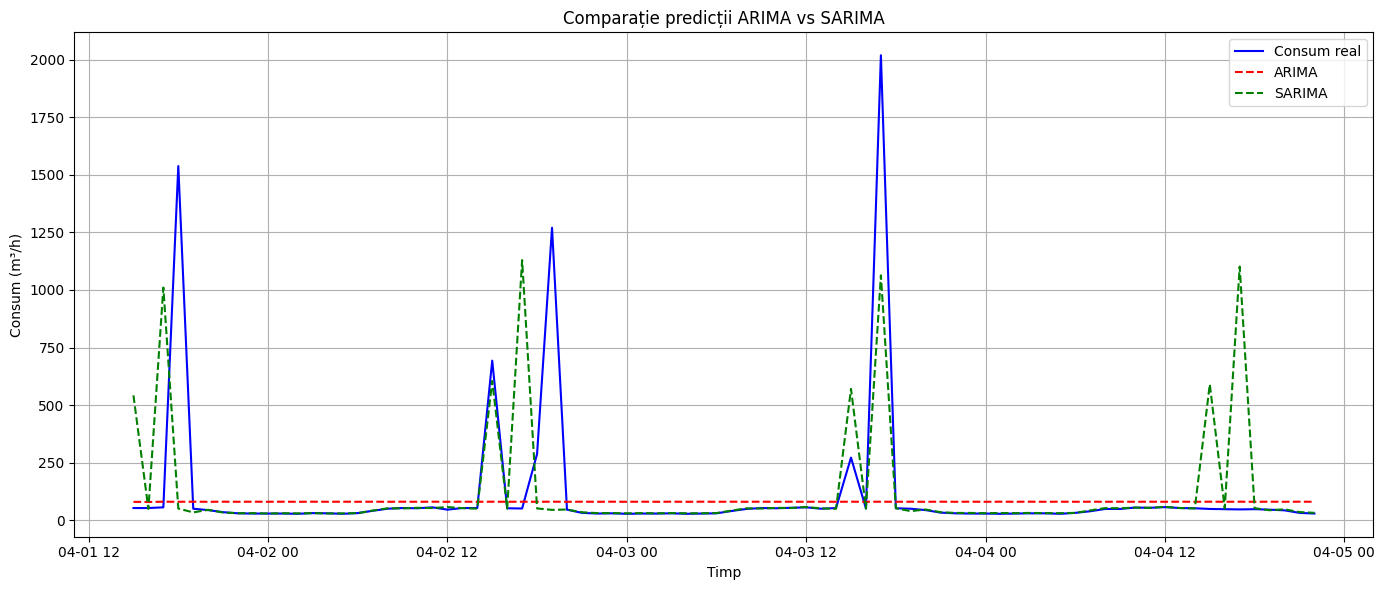

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error

# 1. Citim fișierul
df = pd.read_csv("procesat_consum_irigare.csv")
df["x"] = pd.to_datetime(df["x"])
df.set_index("x", inplace=True)
df = df.sort_index()

# 2. Împărțirea în train/test (80% / 20%)
n = len(df)
train_size = int(n * 0.8)
train = df.iloc[:train_size]
test = df.iloc[train_size:]

# 3. Model ARIMA
model_arima = ARIMA(train["y"], order=(3,1,2))
model_arima_fit = model_arima.fit()
forecast_arima = model_arima_fit.forecast(steps=len(test))

# 4. Model SARIMA (sezonalitate zilnică = 24h)
model_sarima = SARIMAX(train["y"], order=(3,1,2), seasonal_order=(1,1,1,24))
model_sarima_fit = model_sarima.fit()
forecast_sarima = model_sarima_fit.forecast(steps=len(test))

# 5. Calcul RMSE
rmse_arima = np.sqrt(mean_squared_error(test["y"], forecast_arima))
rmse_sarima = np.sqrt(mean_squared_error(test["y"], forecast_sarima))
print(f"ARIMA RMSE: {rmse_arima:.2f}")
print(f"SARIMA RMSE: {rmse_sarima:.2f}")

# 6. Plot
plt.figure(figsize=(14,6))
plt.plot(test.index, test["y"], label="Consum real", color='blue')
plt.plot(test.index, forecast_arima, label="ARIMA", color='red', linestyle='--')
plt.plot(test.index, forecast_sarima, label="SARIMA", color='green', linestyle='--')
plt.title("Comparație predicții ARIMA vs SARIMA")
plt.xlabel("Timp")
plt.ylabel("Consum (m³/h)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# 7. Salvare în CSV
comparatie = pd.DataFrame({
    "Timp": test.index,
    "Real": test["y"].values,
    "ARIMA_Predicted": forecast_arima.values,
    "SARIMA_Predicted": forecast_sarima.values
})
comparatie.to_csv("forecast_comparatie.csv", index=False)
